## HW2

### 選用模型: GloVe

GloVe（Global Vectors for Word Representation）是一種基於計數的詞嵌入模型，由 Stanford NLP 小組開發。其通過分析詞彙共現矩陣來獲得詞向量，能捕捉語義和詞義相似性。本次實驗我們將使用 GloVe 的預訓練嵌入向量（6B 300d）。


### Dependency setup

In [2]:
# Install the required packages
print("[pip] Installing required packages...")
%pip install -r requirements.txt --quiet --no-cache-dir
print("[pip] Required packages installed successfully.")

[pip] Installing required packages...
Note: you may need to restart the kernel to use updated packages.
[pip] Required packages installed successfully.



[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Loading modules and data

In [3]:
# Import necessary libraries
import os
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import requests
from tqdm.notebook import tqdm
from zipfile import ZipFile
import numpy as np
from scipy.spatial.distance import cosine
from itertools import product
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

# Download and extract the GloVe embeddings if not present
if not os.path.exists("embeddings_data"):
    os.makedirs("embeddings_data")
if not os.path.exists("embeddings_data/glove.6B.300d.txt"):
    response = requests.get("http://nlp.stanford.edu/data/glove.6B.zip", stream=True)
    with open("embeddings_data/glove.6B.zip", "wb") as f:
        for data in tqdm(
            response.iter_content(chunk_size=8192),
            total=int(response.headers.get("content-length", 0)) // 8192,
            desc="Downloading",
        ):
            f.write(data)
    with ZipFile("embeddings_data/glove.6B.zip", "r") as zip_ref:
        zip_ref.extract("glove.6B.300d.txt", "embeddings_data")

Downloading:   0%|          | 0/105246 [00:00<?, ?it/s]

### Task 1: Deriving a word embedding model



In [5]:
# Class of GloVe embeddings
class GloVeEmbeddings:
    def __init__(self, file_path: str):
        self.embeddings_dict = {}
        with open(file_path, "r", encoding="utf-8") as f:
            for line in tqdm(f, desc="Loading embeddings", total=400000):
                values = line.strip().split()
                word = values[0]
                embedding = np.array(values[1:], dtype="float32")
                self.embeddings_dict[word] = embedding

    def get_embedding(self, word: str) -> np.ndarray:
        if word in self.embeddings_dict:
            return self.embeddings_dict[word]
        return np.zeros(300, dtype="float32")

    def get_similarity(self, word1: str, word2: str) -> float:
        embedding1 = self.get_embedding(word1)
        embedding2 = self.get_embedding(word2)
        if np.count_nonzero(embedding1) == 0 or np.count_nonzero(embedding2) == 0:
            return 0.0
        return 1 - cosine(embedding1, embedding2)

    def predict_analogy(
        self, embeddings1: np.ndarray, embeddings2: np.ndarray, embeddings3: np.ndarray
    ) -> list:
        if not hasattr(self, "faiss_index"):
            embeddings_array = np.array(
                list(self.embeddings_dict.values()), dtype=np.float32
            )
            self.faiss_index = faiss.IndexFlatL2(embeddings_array.shape[1])
            self.faiss_index.add(embeddings_array)
            self.words = np.array(list(self.embeddings_dict.keys()))
        analogy_vectors = embeddings2 - embeddings1 + embeddings3
        _, indices = self.faiss_index.search(analogy_vectors, 5)
        top_words = [
            [self.words[i] for i in indices[j]] for j in range(analogy_vectors.shape[0])
        ]
        return top_words


# Load the GloVe embeddings
glove_embeddings = GloVeEmbeddings("embeddings_data/glove.6B.300d.txt")

Loading embeddings:   0%|          | 0/400000 [00:00<?, ?it/s]

### Task 2: Using word embedding for word similarity estimation



In [6]:
# Load the WordSim-353 dataset
word353 = pd.read_csv("word353/combined.csv", encoding="utf-8-sig")

# Preprocess the dataset
word353 = word353.rename(columns={"Word 1": "word1", "Word 2": "word2", "Human (mean)": "human_score"})

# Estimate the similarity scores using GloVe embeddings
word353["model_score"] = [
    glove_embeddings.get_similarity(word1, word2) * 5 + 5
    for word1, word2 in zip(word353["word1"], word353["word2"])
]
word353["absolute_difference"] = np.abs(word353["human_score"] - word353["model_score"])

# Save the results to a CSV file
if not os.path.exists("results"):
    os.makedirs("results")
word353.to_csv("results/word353_similarity.csv", index=False, encoding="utf-8-sig")
print("[word353] Similarity scores estimated and saved to results/word353_similarity.csv")

# Calculate the statistics of the output
print("Absolute differences between human and model scores:")
print(f"    Mean: {word353['absolute_difference'].mean()}")
print(f"    Median: {word353['absolute_difference'].median()}")
print(f"    Standard Deviation: {word353['absolute_difference'].std()}")
print(f"    Minimum: {word353['absolute_difference'].min()}")
print(f"    Maximum: {word353['absolute_difference'].max()}")
print("Spearman and Pearson correlations between human and model scores:")
print(f"    Spearman: {spearmanr(word353['human_score'], word353['model_score']).correlation}")
print(f"    Pearson: {pearsonr(word353['human_score'], word353['model_score']).correlation}")

[word353] Similarity scores estimated and saved to results/word353_similarity.csv
Absolute differences between human and model scores:
    Mean: 1.515773478607956
    Median: 1.1190624237060547
    Standard Deviation: 1.29005238968994
    Minimum: 0.0
    Maximum: 5.215429382324219
Spearman and Pearson correlations between human and model scores:
    Spearman: 0.5170193856779319
    Pearson: 0.5209314021591578


### Task 3: Using word embedding for analogy prediction



[bats] BATS dataset loaded successfully.
[bats] Estimating analogy predictions...
[bats] Analogy predictions estimated successfully.


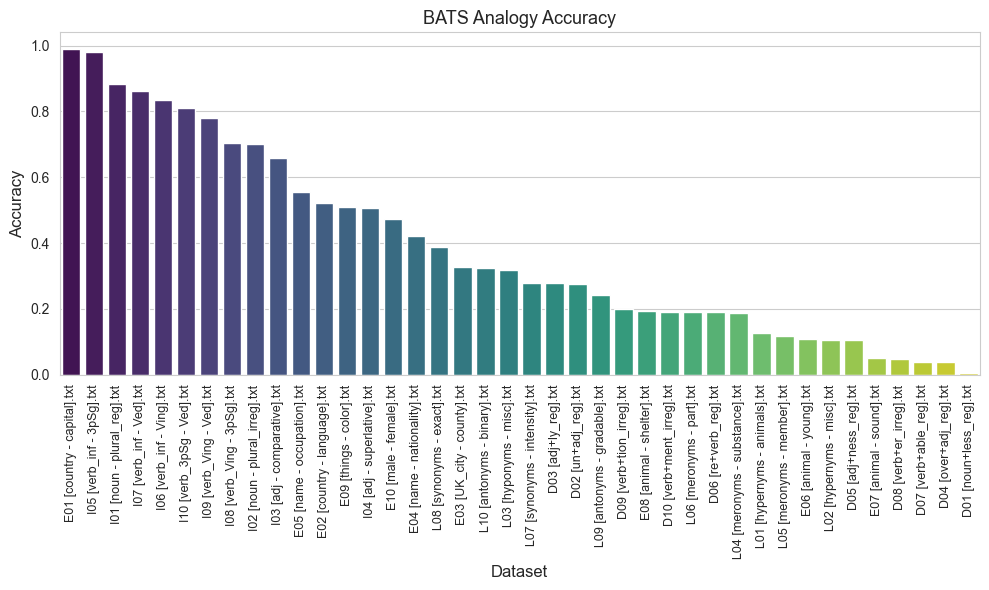

In [7]:
# Load the BATS dataset
bats = {}
for subdir, dirs, files in os.walk("bats"):
    for filename in files:
        if not filename.endswith(".txt"):
            continue
        file_path = os.path.join(subdir, filename)
        bats[filename] = []
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                original, analogies = line.strip().split()
                analogies = analogies.split("/")
                bats[filename].append((original, analogies))
print("[bats] BATS dataset loaded successfully.")

# Estimate the analogy predictions using GloVe embeddings
print("[bats] Estimating analogy predictions...")
bats_results = {}
for filename, data in bats.items():
    bats_results[filename] = {"correct": 0, "incorrect": 0}
    embeddings1, embeddings2, embeddings3 = [], [], []
    answers = []
    for (word1, word2), (word3, word4) in product(list(data), repeat=2):
        if word1 == word3:
            continue
        embeddings1.append(glove_embeddings.get_embedding(word1))
        embeddings2.append(
            np.mean([glove_embeddings.get_embedding(w) for w in word2], axis=0)
        )
        embeddings3.append(glove_embeddings.get_embedding(word3))
        answers.append(word4)
    predicted_words = glove_embeddings.predict_analogy(
        np.array(embeddings1, dtype=np.float32),
        np.array(embeddings2, dtype=np.float32),
        np.array(embeddings3, dtype=np.float32),
    )
    for top_words, answer in zip(predicted_words, answers):
        for predicted_word in top_words:
            if predicted_word in answer:
                bats_results[filename]["correct"] += 1
                break
        else:
            bats_results[filename]["incorrect"] += 1
print("[bats] Analogy predictions estimated successfully.")

# Save the results to a CSV file
if not os.path.exists("results"):
    os.makedirs("results")
filenames = list(bats_results.keys())
glove_accuracy = [
    bats_results[filename]["correct"] / (bats_results[filename]["correct"] + bats_results[filename]["incorrect"])
    for filename in filenames
]
bats_data = pd.DataFrame({"dataset": filenames, "glove_accuracy": glove_accuracy})
bats_data.to_csv("results/bats_analogy_accuracy.csv", index=False, encoding="utf-8-sig")

# Plot the results
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sorted_data = bats_data.sort_values("glove_accuracy", ascending=False)
bar_plot = sns.barplot(
    x="dataset", y="glove_accuracy", data=sorted_data, palette="viridis", hue="dataset"
)

# Customize the plot
plt.title("BATS Analogy Accuracy", fontsize=13)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.savefig("results/bats_analogy_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 4: Compare with other document similarity estimation methods



[bert] Downloading or caching the BERT model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

D:\Nick_Chang\NTUT\3rd\NLP\HW2\venv\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\Nick_Chang\NTUT\3rd\NLP\HW2\embeddings_data\models--mixedbread-ai--mxbai-embed-large-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/114k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

[bert] BERT model downloaded or cached successfully.
[comparison] All similarity scores calculated and saved.


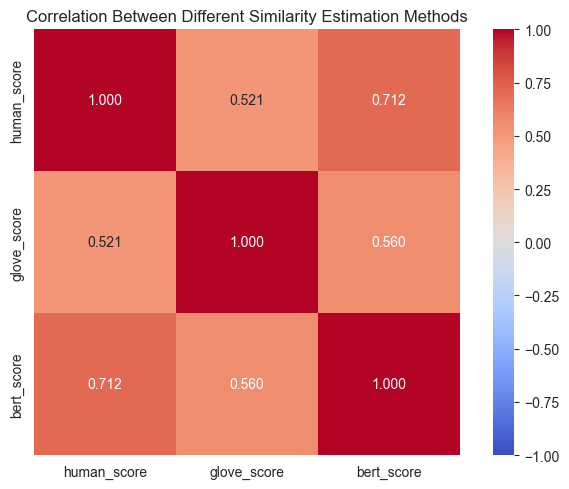

In [8]:
# Prepare the BERT model
if not os.path.exists("embeddings_data"):
    os.makedirs("embeddings_data")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
print("[bert] Downloading or caching the BERT model...")
bert_model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1", cache_folder="embeddings_data")
print("[bert] BERT model downloaded or cached successfully.")

# Predict the similarity scores using all models
word353 = pd.read_csv("word353/combined.csv", encoding="utf-8-sig")
word353 = word353.rename(columns={"Word 1": "word1", "Word 2": "word2", "Human (mean)": "human_score"})

# GloVe similarity scores
word353["glove_score"] = [
    glove_embeddings.get_similarity(word1, word2) * 5 + 5
    for word1, word2 in zip(word353["word1"], word353["word2"])
]

# BERT similarity scores
word353["bert_score"] = [
    bert_model.similarity(bert_model.encode(word1), bert_model.encode(word2)).tolist()[0][0] * 5 + 5
    for word1, word2 in zip(word353["word1"], word353["word2"])
]

# Save results
word353.to_csv("results/word353_all_similarities.csv", index=False, encoding="utf-8-sig")
print("[comparison] All similarity scores calculated and saved.")

# Visualize the correlation matrix
correlation_matrix = word353[["human_score", "glove_score", "bert_score"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1, square=True)
plt.title('Correlation Between Different Similarity Estimation Methods')
plt.tight_layout()
plt.savefig("results/similarity_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Task5 Apply word embeddings in other tasks


In [17]:
import random
import os

# 1. 人名 (PER)、公司名 (ORG)、地名 (LOC)
persons = ["Steve", "Jobs", "Elon", "Musk", "Bill", "Gates", "Sundar", "Pichai", "Jeff", "Bezos", "Mark", "Zuckerberg", "Peter", "Anna", "Tom", "Lucy"]
organizations = ["Apple", "Microsoft", "Google", "Amazon", "Facebook", "SpaceX", "Netflix"]
locations = ["California", "Texas", "New York", "London", "Paris", "Tokyo", "library", "school", "hospital", "park", "museum"]

# 2. 常用動詞與連接詞 (O)
verbs = ["founded", "created", "leads", "manages", "works", "visits", "invests", "studies", "learns"]
prepositions = ["in", "at", "from", "to", "with"]
others = [".", "!", "is", "a", "the", "and"]

# 3. 設計模板，生成句子
def generate_sentence():
    template_type = random.choice(["person-org", "person-loc", "org-loc", "person-simpleloc"])
    sentence = []

    if template_type == "person-org":
        p1, p2 = random.sample(persons, 2)
        org = random.choice(organizations)
        verb = random.choice(verbs)
        sentence = [(p1, "PER"), (p2, "PER"), (verb, "O"), (org, "ORG"), (".", "O")]

    elif template_type == "person-loc":
        p1 = random.choice(persons)
        loc = random.choice(locations)
        prep = random.choice(prepositions)
        verb = random.choice(verbs)
        sentence = [(p1, "PER"), (verb, "O"), (prep, "O"), (loc, "LOC"), (".", "O")]

    elif template_type == "org-loc":
        org = random.choice(organizations)
        loc = random.choice(locations)
        verb = random.choice(verbs)
        prep = random.choice(prepositions)
        sentence = [(org, "ORG"), (verb, "O"), (prep, "O"), (loc, "LOC"), (".", "O")]

    else:  # person-simpleloc
        p1 = random.choice(persons)
        loc = random.choice(locations)
        verb = random.choice(["visits", "studies", "learns"])
        sentence = [(p1, "PER"), (verb, "O"), ("at", "O"), (loc, "LOC"), (".", "O")]

    return sentence

# 4. 生成50句資料
def generate_dataset(num_sentences=50):
    random.seed(42)
    sentences = [generate_sentence() for _ in range(num_sentences)]
    return sentences

# 5. 寫入檔案
def save_dataset(sentences, path="ner_data/ner_dataset.txt"):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for sent in sentences:
            for word, tag in sent:
                f.write(f"{word}\t{tag}\n")
            f.write("\n")  # 空白行分句
    print(f"成功寫入 {path}！")

if __name__ == "__main__":
    sentences = generate_dataset(50)
    save_dataset(sentences, "ner_data/ner_dataset.txt")


成功寫入 ner_data/ner_dataset.txt！


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

# --- 1. 載入 NER 資料集 ---
def load_dataset(filepath):
    sentences, tags = [], []
    current_sentence, current_tags = [], []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line == "":
                if current_sentence:
                    sentences.append(current_sentence)
                    tags.append(current_tags)
                    current_sentence, current_tags = [], []
                continue
            word, tag = line.split("\t")
            current_sentence.append(word)
            current_tags.append(tag)
    return sentences, tags

# --- 2. 標籤字典 ---
tag_to_ix = {"PER": 0, "ORG": 1, "LOC": 2, "O": 3}
ix_to_tag = {v: k for k, v in tag_to_ix.items()}

# --- 3. Dataset ---
class NERDataset(Dataset):
    def __init__(self, sentences, tags, glove_embeddings):
        self.sentences = sentences
        self.tags = tags
        self.glove = glove_embeddings

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        tag_seq = self.tags[idx]
        embeddings = np.array([self.glove.get_embedding(w) for w in sentence], dtype=np.float32)
        labels = torch.tensor([tag_to_ix[t] for t in tag_seq], dtype=torch.long)
        return torch.tensor(embeddings, dtype=torch.float32), labels

# --- 4. Bi-LSTM NER 模型 ---
class BiLSTM_NER(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, tagset_size):
        super(BiLSTM_NER, self).__init__()
        self.bilstm = nn.LSTM(embedding_dim, hidden_dim // 2, num_layers=1, bidirectional=True)
        self.fc = nn.Linear(hidden_dim, tagset_size)

    def forward(self, embeds):
        lstm_out, _ = self.bilstm(embeds.view(len(embeds), 1, -1))
        tag_space = self.fc(lstm_out.view(len(embeds), -1))
        tag_scores = torch.log_softmax(tag_space, dim=1)
        return tag_scores

# --- 5. 訓練設定 ---
embedding_dim = 300  # GloVe 300d
hidden_dim = 128
batch_size = 1
epochs = 40

# 假設你已經有一個 GloVeEmbeddings 實例 glove_embeddings
sentences, tags = load_dataset("ner_data/ner_dataset.txt")
train_dataset = NERDataset(sentences, tags, glove_embeddings)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = BiLSTM_NER(embedding_dim, hidden_dim, len(tag_to_ix))
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 6. 開始訓練 ---
for epoch in range(epochs):
    total_loss = 0
    for inputs, labels in train_loader:
        model.zero_grad()
        inputs = inputs.squeeze(0)  # [seq_len, 300]
        labels = labels.squeeze(0)  # [seq_len]
        tag_scores = model(inputs)
        loss = loss_function(tag_scores, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

# --- 7. 測試新句子 ---
def predict(model, sentence_words):
    model.eval()
    inputs = torch.tensor(np.array([glove_embeddings.get_embedding(w) for w in sentence_words], dtype=np.float32), dtype=torch.float32)
    with torch.no_grad():
        tag_scores = model(inputs)
        predicted = torch.argmax(tag_scores, dim=1)
    return [ix_to_tag[i.item()] for i in predicted]

# 測試看看
new_sentence = [
    ["Tim", "Cook", "leads", "Apple", "."],
    ["Peter","works","in" ,"NTUT","."],
    ["JYKuo","is","learning","math","at","library","."]
]

for i in new_sentence:
    predicted_tags = predict(model, i)
    print("\n測試句子:", i)
    print("預測標籤:", predicted_tags)


Epoch 1/40 - Loss: 43.5867
Epoch 2/40 - Loss: 16.3062
Epoch 3/40 - Loss: 9.0124
Epoch 4/40 - Loss: 6.7997
Epoch 5/40 - Loss: 5.7236
Epoch 6/40 - Loss: 5.1041
Epoch 7/40 - Loss: 5.2218
Epoch 8/40 - Loss: 4.5011
Epoch 9/40 - Loss: 4.0339
Epoch 10/40 - Loss: 4.5584
Epoch 11/40 - Loss: 3.6061
Epoch 12/40 - Loss: 3.5301
Epoch 13/40 - Loss: 3.1581
Epoch 14/40 - Loss: 2.7796
Epoch 15/40 - Loss: 2.7442
Epoch 16/40 - Loss: 2.4753
Epoch 17/40 - Loss: 2.4587
Epoch 18/40 - Loss: 1.8825
Epoch 19/40 - Loss: 1.7500
Epoch 20/40 - Loss: 1.6071
Epoch 21/40 - Loss: 1.3386
Epoch 22/40 - Loss: 1.8530
Epoch 23/40 - Loss: 1.3126
Epoch 24/40 - Loss: 1.4654
Epoch 25/40 - Loss: 1.2410
Epoch 26/40 - Loss: 1.2713
Epoch 27/40 - Loss: 1.0621
Epoch 28/40 - Loss: 1.0090
Epoch 29/40 - Loss: 0.9690
Epoch 30/40 - Loss: 1.1140
Epoch 31/40 - Loss: 1.1422
Epoch 32/40 - Loss: 1.1470
Epoch 33/40 - Loss: 1.0789
Epoch 34/40 - Loss: 1.0010
Epoch 35/40 - Loss: 1.0041
Epoch 36/40 - Loss: 0.9950
Epoch 37/40 - Loss: 0.9969
Epoch 38